In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/AML_LAB/multiclass_classification_dataset_500_samples.csv")
df.head()

,Study_Hours,Attendance_Percentage,Assignment_Score,Internal_Marks,Participation,Internet_Access,Previous_Grade,Performance_Level
0,22.48,84.26,86.79,76.68,Medium,Yes,B,1
1,19.31,94.09,81.10,56.73,Low,Yes,B,1
2,23.24,61.01,70.72,52.73,Medium,Yes,A,0
3,27.62,80.63,62.24,64.95,Low,Yes,C,0
4,18.83,68.49,78.38,62.45,High,Yes,B,0


In [4]:
df["Performance_Level"].unique()

array([1, 0, 2])

In [5]:
from sklearn.model_selection import train_test_split

x = pd.get_dummies(df.drop("Performance_Level", axis=1))
y = df["Performance_Level"]

x_train, x_test, y_train_true, y_test_true = train_test_split(x, y, test_size=0.3, random_state=42)
print(x.shape)
print(y.shape)

(500, 12)
(500,)


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
xgb = XGBClassifier(use_label_encoder=True, eval_metric='mlogloss', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [8]:
rf.fit(x_train, y_train_true)
dt.fit(x_train, y_train_true)
lr.fit(x_train, y_train_true)
xgb.fit(x_train, y_train_true)
knn.fit(x_train, y_train_true)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(

KNeighborsClassifier()

In [9]:
rf.fit(x_train, y_train_true)
dt.fit(x_train, y_train_true)
lr.fit(x_train, y_train_true)
xgb.fit(x_train, y_train_true)
knn.fit(x_train, y_train_true)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:18:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(

KNeighborsClassifier()

In [10]:
rf_pred = rf.predict(x_test)
dt_pred = dt.predict(x_test)
lr_pred = lr.predict(x_test)
xgb_pred = xgb.predict(x_test)
knn_pred = knn.predict(x_test)

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

rf_accuracy             = accuracy_score(y_test_true, rf_pred)
rf_precision            = precision_score(y_test_true, rf_pred, average='weighted')
rf_recall               = recall_score(y_test_true, rf_pred, average='weighted')
rf_f1_micro             = f1_score(y_test_true, rf_pred, average='micro')
rf_f1_macro             = f1_score(y_test_true, rf_pred, average='macro')
rf_f1_weighted          = f1_score(y_test_true, rf_pred, average='weighted')
rf_roc_auc              = roc_auc_score(y_test_true, rf.predict_proba(x_test), multi_class='ovr', average='weighted')

dt_accuracy             = accuracy_score(y_test_true, dt_pred)
dt_precision            = precision_score(y_test_true, dt_pred, average='weighted')
dt_recall               = recall_score(y_test_true, dt_pred, average='weighted')
dt_f1_micro             = f1_score(y_test_true, dt_pred, average='micro')
dt_f1_macro             = f1_score(y_test_true, dt_pred, average='macro')
dt_f1_weighted          = f1_score(y_test_true, dt_pred, average='weighted')
dt_roc_auc              = roc_auc_score(y_test_true, dt.predict_proba(x_test), multi_class='ovr', average='weighted')

lr_accuracy             = accuracy_score(y_test_true, lr_pred)
lr_precision            = precision_score(y_test_true, lr_pred, average='weighted')
lr_recall               = recall_score(y_test_true, lr_pred, average='weighted')
lr_f1_micro             = f1_score(y_test_true, lr_pred, average='micro')
lr_f1_macro             = f1_score(y_test_true, lr_pred, average='macro')
lr_f1_weighted          = f1_score(y_test_true, lr_pred, average='weighted')
lr_roc_auc              = roc_auc_score(y_test_true, lr.predict_proba(x_test), multi_class='ovr', average='weighted')

xgb_accuracy            = accuracy_score(y_test_true, xgb_pred)
xgb_precision           = precision_score(y_test_true, xgb_pred, average='weighted')
xgb_recall              = recall_score(y_test_true, xgb_pred, average='weighted')
xgb_f1_micro            = f1_score(y_test_true, xgb_pred, average='micro')
xgb_f1_macro            = f1_score(y_test_true, xgb_pred, average='macro')
xgb_f1_weighted         = f1_score(y_test_true, xgb_pred, average='weighted')
xgb_roc_auc             = roc_auc_score(y_test_true, xgb.predict_proba(x_test), multi_class='ovr', average='weighted')

knn_accuracy            = accuracy_score(y_test_true, knn_pred)
knn_precision           = precision_score(y_test_true, knn_pred, average='weighted')
knn_recall              = recall_score(y_test_true, knn_pred, average='weighted')
knn_f1_micro            = f1_score(y_test_true, knn_pred, average='micro')
knn_f1_macro            = f1_score(y_test_true, knn_pred, average='macro')
knn_f1_weighted         = f1_score(y_test_true, knn_pred, average='weighted')
knn_roc_auc             = roc_auc_score(y_test_true, knn.predict_proba(x_test), multi_class='ovr', average='weighted')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [12]:
Model=["RF","DT","MLR","XGB","KNN"]

Accuracy = [rf_accuracy, dt_accuracy, lr_accuracy, xgb_accuracy, knn_accuracy]
Precision = [rf_precision, dt_precision, lr_precision, xgb_precision, knn_precision]
Recall = [rf_recall, dt_recall, lr_recall, xgb_recall, knn_recall]
F1_micro = [rf_f1_micro, dt_f1_micro, lr_f1_micro, xgb_f1_micro, knn_f1_micro]
F1_macro = [rf_f1_macro, dt_f1_macro, lr_f1_macro, xgb_f1_macro, knn_f1_macro]
F1_weighted = [rf_f1_weighted, dt_f1_weighted, lr_f1_weighted, xgb_f1_weighted, knn_f1_weighted]
Roc_auc = [rf_roc_auc, dt_roc_auc, lr_roc_auc, xgb_roc_auc, knn_roc_auc]

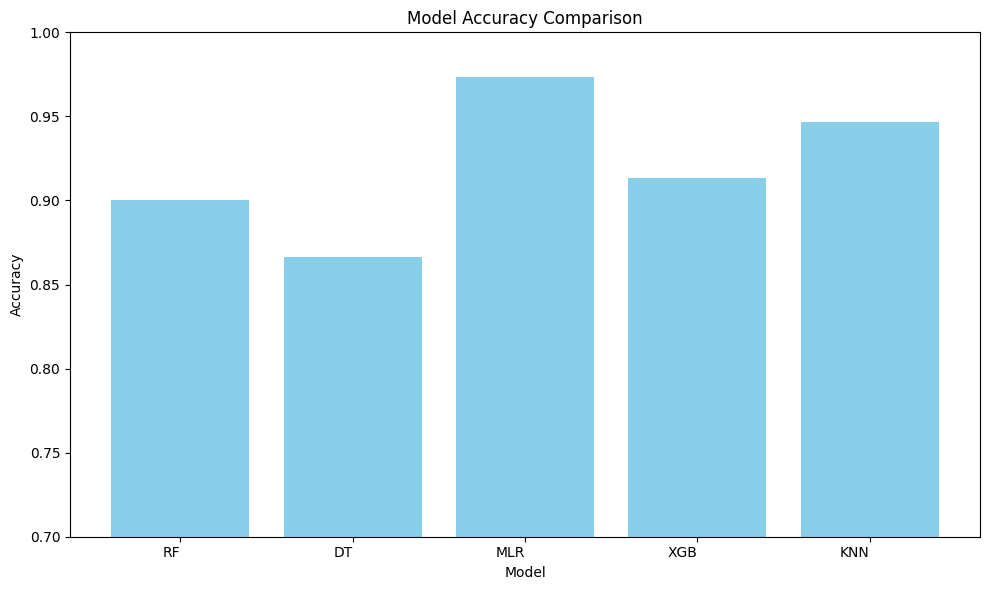

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, Accuracy, color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

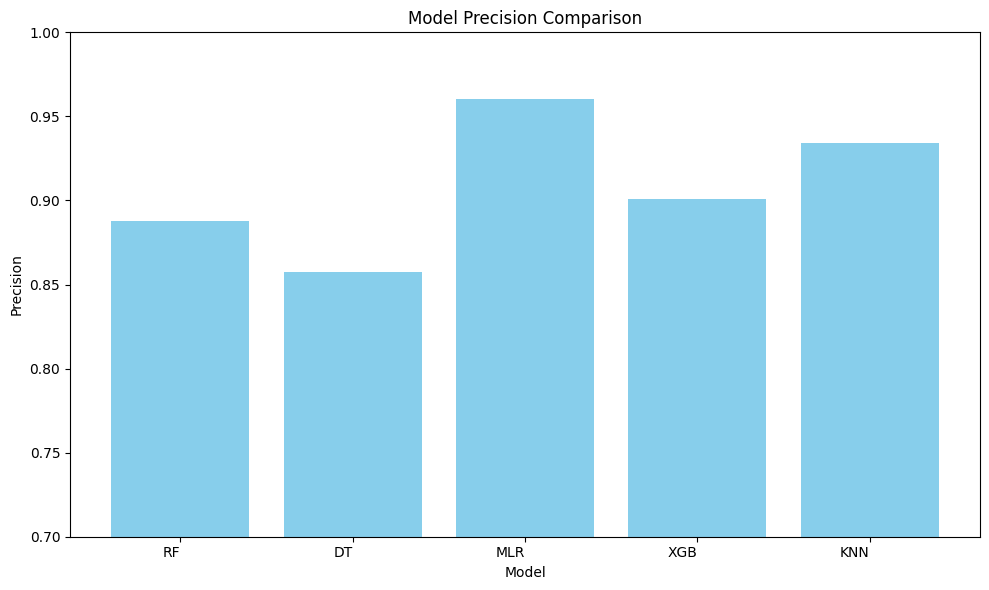

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, Precision, color='skyblue')
plt.title('Model Precision Comparison')
plt.ylabel('Precision')
plt.xlabel('Model')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

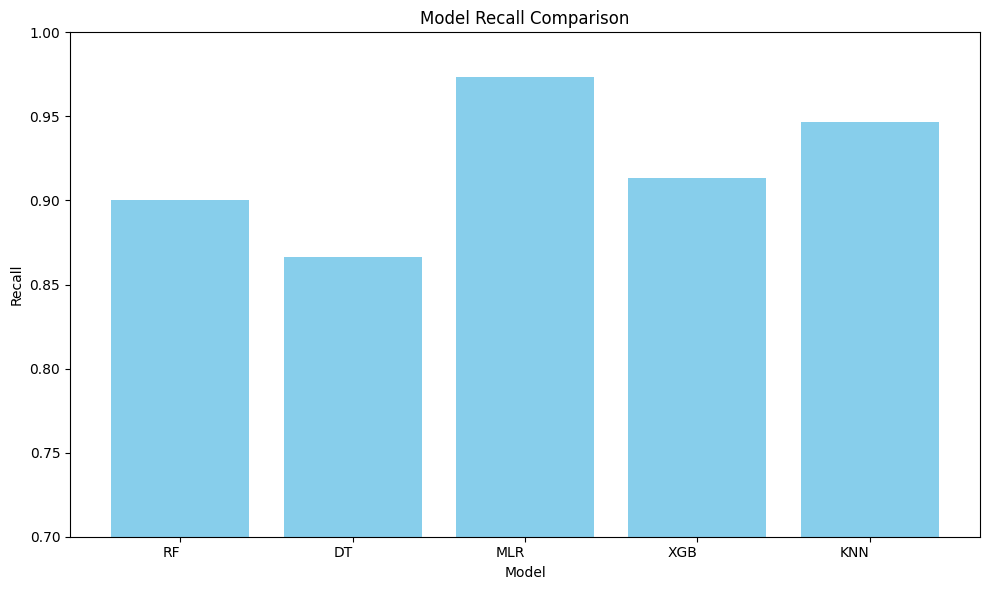

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, Recall, color='skyblue')
plt.title('Model Recall Comparison')
plt.ylabel('Recall')
plt.xlabel('Model')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

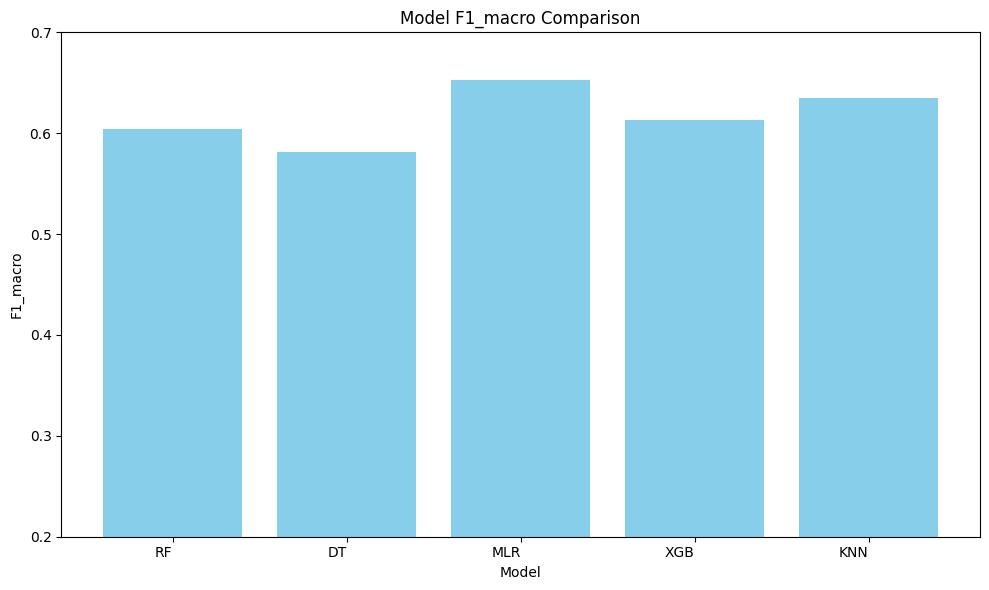

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, F1_macro, color='skyblue')
plt.title('Model F1_macro Comparison')
plt.ylabel('F1_macro')
plt.xlabel('Model')
plt.ylim(0.2, 0.7)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

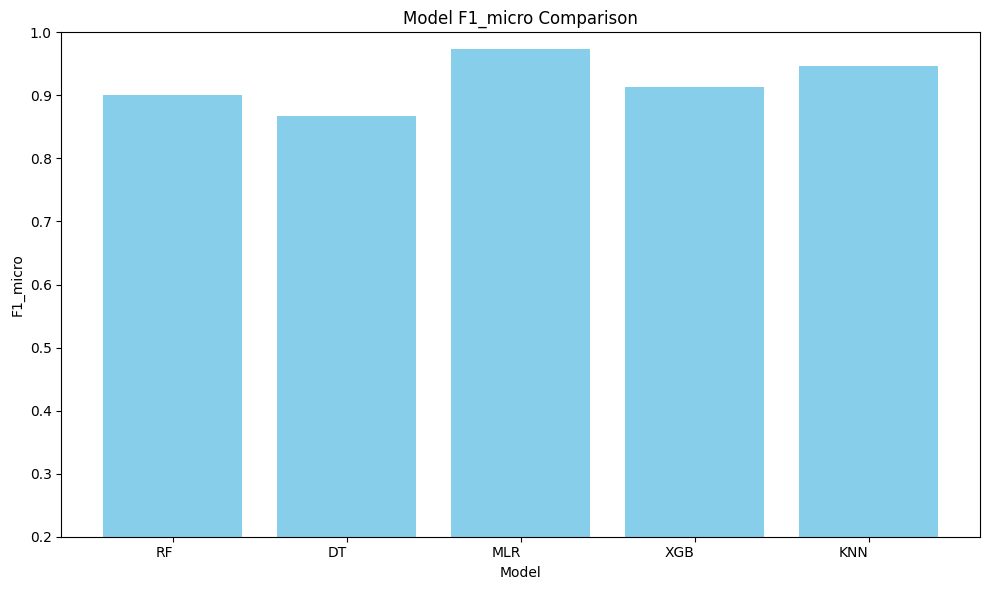

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, F1_micro, color='skyblue')
plt.title('Model F1_micro Comparison')
plt.ylabel('F1_micro')
plt.xlabel('Model')
plt.ylim(0.2, 1.0)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

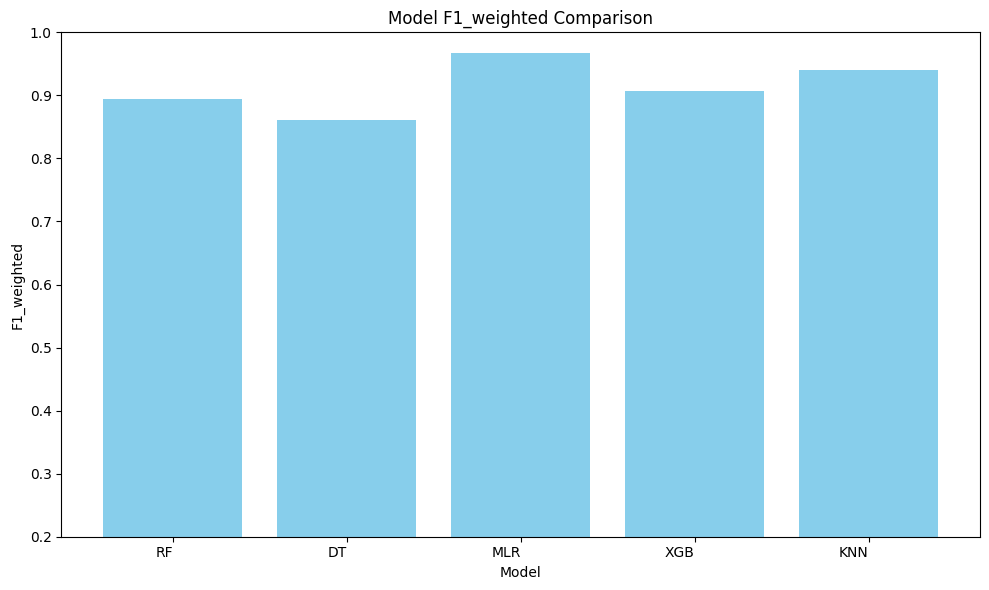

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, F1_weighted, color='skyblue')
plt.title('Model F1_weighted Comparison')
plt.ylabel('F1_weighted')
plt.xlabel('Model')
plt.ylim(0.2, 1.0)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

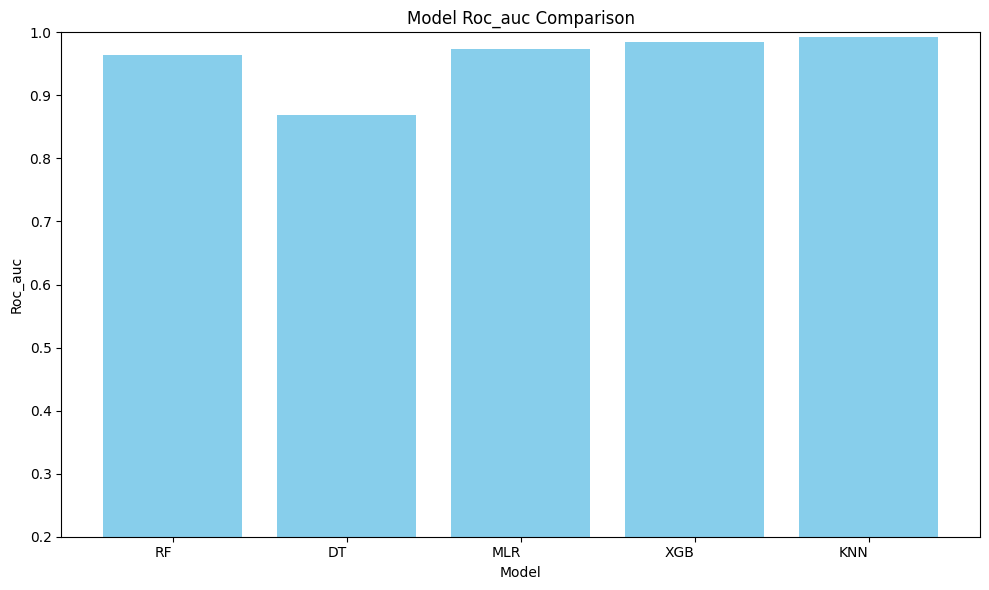

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, Roc_auc, color='skyblue')
plt.title('Model Roc_auc Comparison')
plt.ylabel('Roc_auc')
plt.xlabel('Model')
plt.ylim(0.2, 1.0)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()